# Time series prediction using LSTM

## Dataset
- Daily minimum temperatures in Melbourne, Australia, 1981-1990
- Units: Degrees Celcius

In [1]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.layers import LSTM
from keras  import callbacks
from keras import optimizers
import pandas as pd 
import tensorflow as tf
import numpy as np

Using TensorFlow backend.


## Question 1

### Load the data
- load daily-minimum-temperatures-in-me.csv

In [0]:
# if you are using google colab
from google.colab import files
files.upload()

### Print the data
- First 5 rows only

### Set index column
- Set the DataFrame index using "Date" column

In [19]:
df = pd.read_csv('daily-minimum-temperatures-in-me.csv', index_col='Date')
print(df.head())


            Temperature
Date                   
1981-01-01         20.7
1981-01-02         17.9
1981-01-03         18.8
1981-01-04         14.6
1981-01-05         15.8


In [20]:
df.sort_index(inplace=True)
print('Total rows: {}'.format(len(df)))
df.head()

Total rows: 3650


,Temperature
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
Temperature    3650 non-null float64
dtypes: float64(1)
memory usage: 57.0+ KB


In [22]:
df = df.astype('float32')

## Question 2

### Check the total count of null values in the data

In [8]:
# Null Values?
df.isnull().sum()

Date           0
Temperature    0
dtype: int64

In [9]:
print(df.isnull().any(axis=1).sum())

0


### Drop all the rows with null values
- use dropna() method

In [10]:
df.dropna(inplace=True)

## Question 3

### Describe your dataframe
- use describe() method

In [23]:
#Get statistical analysis of Temperature dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,3650.0,11.177745,4.071843,0.0,8.3,11.0,14.0,26.299999


### Plot the dataframe
- use plot() method

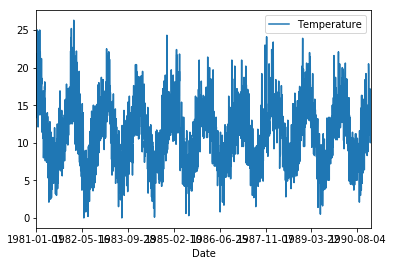

In [24]:
df.plot()

### Get representation of the distribution of data using histogram
- use hist() method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000000006102940>]],
      dtype=object)

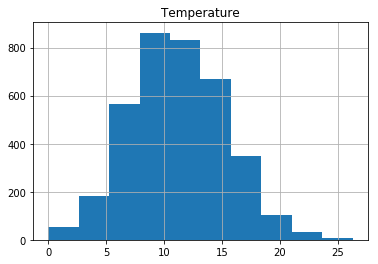

In [12]:
df.hist(bins=10)

### Check minimum and maximum temperature
- use min() and max() methods

In [25]:
# Scaled Data
print('Min', np.min(df))
print('Max', np.max(df))

Min Temperature    0.0
dtype: float32
Max Temperature    26.299999
dtype: float32


## Question 4

### Split the dataset into training and testing
- training data: 75%
- testing data: 25%

In [32]:
#Create the model
train_size = int(len(df) * 0.70)
test_size = len(df - train_size)
print("Total Data Size: ", len(df))
print("Trains Size : ",train_size)
print("Test Size: ", test_size)

Total Data Size:  3650
Trains Size :  2555
Test Size:  3650


In [34]:
train = df[0:train_size]

In [36]:
train.shape

(2555, 1)

In [37]:
test = df[train_size:len(df)]

In [38]:
test.shape

(1095, 1)

In [40]:
print("Total Data Shape : ", df.shape)
print("Train Data Shape : ", train.shape)
print("Test Data Shape : ", test.shape)

Total Data Shape :  (3650, 1)
Train Data Shape :  (2555, 1)
Test Data Shape :  (1095, 1)


### Normalize the data
- normalize temperature values using MinMaxScaler
- feature_range: 0-1
- fit MinMaxScaler on train data and transform it
  - use fit_transform() method
- transform test data using MinMaxScaler object
  - use transform() method

In [41]:
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:334: DataConversionWarning: Data with input dtype float32 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


In [42]:
test = scaler.transform(test)

### Print scaled train and test data
- print only first 5 values

In [45]:
print("Normalized Train Data :\n", train[:5])

Normalized Traind Data :
 [[0.7870723 ]
 [0.68060837]
 [0.71482889]
 [0.55513311]
 [0.60076048]]


In [46]:
print("Normalized Test Data :\n", test[:5])

Normalized Test Data :
 [[0.58174907]
 [0.54372626]
 [0.513308  ]
 [0.57034222]
 [0.5171103 ]]


## Question 5

### Create sequential data
Map the temperature at a particular day 'd' to the temperature at day t
'd+n', where n is any number you define.

For example: to map temperatures of consecutive days, use d+1, i.e. lookback = 1
- Below function takes data as input and returns sequential data.
- X as features and y as labels

In [55]:
import numpy as np
def create_seq_data(data, lookback=1):
    X, y = list(), list()
    for day in range((len(data)-lookback)):
        X.append(data[day: day+lookback, 0])
        y.append(data[day+lookback, 0])
    return np.array(X), np.array(y)

### Use the above function to create train and test sets
- Get X_train and y_train
- Get X_test and y_test
- lookback = 1

In [56]:
look_back = 1
X_train, y_train = create_seq_data(train, look_back)
X_test, y_test = create_seq_data(test, look_back)

### Reshape the data
- Reshape X_train and X_test
- use np.reshape() method
- this is to be done to make the data ready for input in model

In [57]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


### Print shape of data
- print shape of X_train and X_test

In [58]:
print(X_train.shape)
print(X_test.shape)

(2554, 1, 1)
(1094, 1, 1)


## Question 6

### Define sequential model
- initialize a Sequential model
- add an LSTM layer
  - units: 10
  - stateful: True
  - pass a `batch_input_shape` argument to your layer
  - batch_input_shape: (batch_size, look_back, 1)
    - batch_size: 1
    - look_back: 1
- add Dense layer with 1 neuron

In [60]:
#The network has a visible layer with 1 input, a hidden layer with 4 LSTM blocks or neurons, and an output layer that makes a single value prediction. The default sigmoid activation function is used for the LSTM blocks. The network is trained for 100 epochs and a batch size of 1 is used.
#create and fit the LSTM network
batch_size = 1
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(10, batch_input_shape=(batch_size, look_back, 1), stateful=True))
model.add(tf.keras.layers.Dense(1))


## Question 7

### compile your model
- loss: mean_squared_error
- optimizer: adam

In [61]:
model.compile(loss='mean_squared_error', optimizer='adam')


### summarize your model
- use summary() method

In [62]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (1, 10)                   480       
_________________________________________________________________
dense (Dense)                (1, 1)                    11        
Total params: 491
Trainable params: 491
Non-trainable params: 0
_________________________________________________________________


## Question 8

### fit your model
- epochs: 50
- batch_size: 1

In [63]:
model.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=2, shuffle=True)

Train on 2554 samples
Epoch 1/50
2554/2554 - 13s - loss: 0.0143
Epoch 2/50
2554/2554 - 7s - loss: 0.0105
Epoch 3/50
2554/2554 - 6s - loss: 0.0105
Epoch 4/50
2554/2554 - 6s - loss: 0.0104
Epoch 5/50
2554/2554 - 6s - loss: 0.0104
Epoch 6/50
2554/2554 - 6s - loss: 0.0103
Epoch 7/50
2554/2554 - 6s - loss: 0.0103
Epoch 8/50
2554/2554 - 6s - loss: 0.0103
Epoch 9/50
2554/2554 - 6s - loss: 0.0104
Epoch 10/50
2554/2554 - 6s - loss: 0.0103
Epoch 11/50
2554/2554 - 6s - loss: 0.0103
Epoch 12/50
2554/2554 - 6s - loss: 0.0103
Epoch 13/50
2554/2554 - 5s - loss: 0.0103
Epoch 14/50
2554/2554 - 6s - loss: 0.0103
Epoch 15/50
2554/2554 - 6s - loss: 0.0102
Epoch 16/50
2554/2554 - 6s - loss: 0.0103
Epoch 17/50
2554/2554 - 6s - loss: 0.0103
Epoch 18/50
2554/2554 - 6s - loss: 0.0102
Epoch 19/50
2554/2554 - 6s - loss: 0.0101
Epoch 20/50
2554/2554 - 6s - loss: 0.0102
Epoch 21/50
2554/2554 - 6s - loss: 0.0102
Epoch 22/50
2554/2554 - 6s - loss: 0.0102
Epoch 23/50
2554/2554 - 6s - loss: 0.0102
Epoch 24/50
2554/255

## Question 9

### make predictions on train data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [64]:
trainPredict = model.predict(X_train, batch_size=batch_size)

### reset model state
- if you are using stateful=True in your model then you should call reset_states every time, when you want to make consecutive model calls independent.
- use reset_states() method

In [65]:
model.reset_states()

### make predictions on test data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [66]:
testPredict = model.predict(X_test, batch_size=batch_size)

## Question 10

### Inverse train predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [67]:
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])


### Inverse test predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [68]:
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])

### Evaluate train predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print training RMSE

In [70]:
import math
from sklearn.metrics import mean_squared_error

In [71]:
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

Train Score: 2.67 RMSE


### Evaluate test predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print testing RMSE

In [72]:
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 2.54 RMSE
